#### Exact Matching  Evaluierung

In [1]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from latex_functions_p1 import *
from evaluate_functions_p1 import *
from plot_functions_p1 import *

### Wähle den evaluations Ordner

In [2]:
versuch_ordner = "modelle_prompt2/" 
versuch_name = "modell_prompt2"

label_folder = '../input/lct_p1'
raw_lct_text_folder = '../input/lct_txt'
model_output_folder = versuch_ordner + 'model_output'
models = [folder for folder in os.listdir(model_output_folder) if os.path.isdir(os.path.join(model_output_folder, folder))]
models

[' Naive greedy match (Prompt 2)',
 '70b_EP10_r256',
 '8B_EP10_r128',
 'Gemma-27b_0_shot',
 'Gemma-27b_5_shot',
 'Llama-2-70B_3_shot',
 'Llama-3-70B_0_shot',
 'Llama-3-8B-0_shot',
 'Llama-3-8B-Instruct_5_shot',
 'Llama-3.1-70B-5_shot',
 'Llama-3.1-70B-Reflect_0_shot',
 'Llama-3.1-70B-Reflect_5_shot',
 'Llama-3.1-8B-Instruct_5_shot',
 'Llama3-70b_5_shot',
 'Qwen2-72B_0_shot',
 'Qwen2-72B_15_shot',
 'Qwen2-72B_5_shot']

In [3]:
all_metrics = {}
for model in models:
    model_folder = os.path.join(model_output_folder, model, 'output')
    metrics = evaluate_models(label_folder, model_folder, model, raw_lct_text_folder)
    all_metrics[model] = metrics

In [4]:
all_metrics

{' Naive greedy match (Prompt 2)': {'AND': {'precision': 17.5,
   'recall': 86.41975308641975,
   'f1': 29.10602910602911,
   'accuracy': 86.41975308641975,
   'total_label': 162,
   'total_model': 811,
   'correct_count': 140,
   'low_tp_ncts': []},
  'OR': {'precision': 55.61936013125512,
   'recall': 84.75,
   'f1': 67.16196136701336,
   'accuracy': 84.75,
   'total_label': 800,
   'total_model': 1231,
   'correct_count': 678,
   'low_tp_ncts': []},
  'NOT': {'precision': 61.935483870967744,
   'recall': 51.891891891891895,
   'f1': 56.470588235294116,
   'accuracy': 51.891891891891895,
   'total_label': 185,
   'total_model': 157,
   'correct_count': 96,
   'low_tp_ncts': ['NCT03865121']},
  'average_missing_percentage': 0.6574334719494416,
  'average_zuviel_percentage': 1.326082269326042,
  'total_missing_words': Counter({'and/or': 22,
           'kg/m2': 9,
           'mg/dL': 8,
           '(no': 4,
           '+/-': 3,
           '(with': 3,
           'his/her': 3,
           

### Missing Words PCT

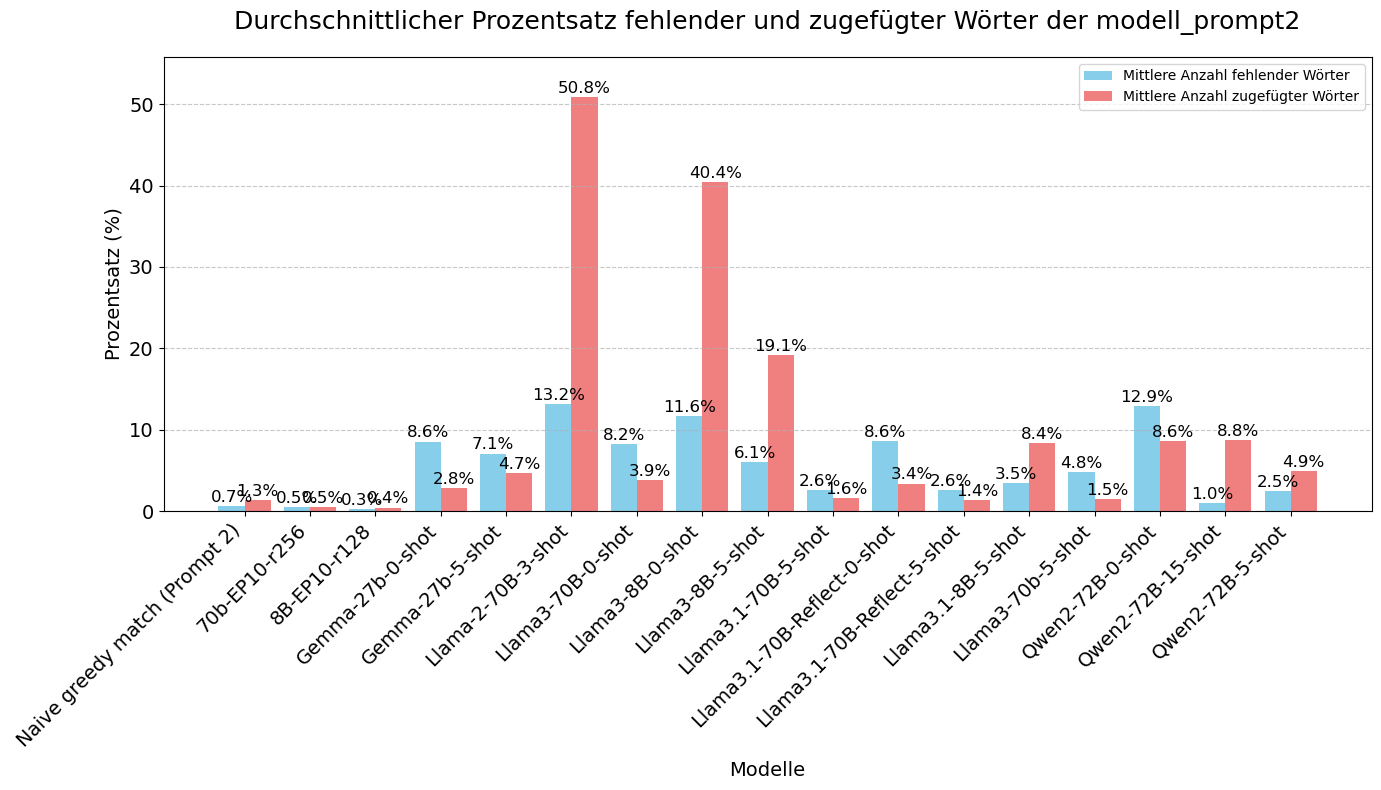

In [5]:
plot_avg_pct(all_metrics, versuch_name)

In [6]:
# n-shot P/R/F1 über alle Operatoren 
#calculate_mean_excel(all_metrics, model_names="0_shot")  


In [7]:
def calculate_mean_excel(data, model_names, file_path='data/excel/llama70b_mean.xlsx'):
    n_shot_models = [model for model in data.keys()]
    operators = ['AND', 'OR', 'NOT']
    metrics = ['precision', 'recall', 'f1']

    all_metrics = {op: {metric: [] for metric in metrics} for op in operators}
    missing_percentages = []
    excess_percentages = []

    for model in n_shot_models:
        for op in operators:
            for metric in metrics:
                all_metrics[op][metric].append(data[model][op][metric])

        missing_percentages.append(data[model]['average_missing_percentage'])
        excess_percentages.append(data[model]['average_zuviel_percentage'])

    result = {}
    for op in operators:
        for metric in metrics:
            result[f'{op}_avg_{metric}'] = np.mean(all_metrics[op][metric])
            result[f'{op}_std_{metric}'] = np.std(all_metrics[op][metric])

    result['average_missing_percentage'] = np.mean(missing_percentages)
    result['average_excess_percentage'] = np.mean(excess_percentages)
    result['std_missing_percentage'] = np.std(missing_percentages)
    result['std_excess_percentage'] = np.std(excess_percentages)

    df = pd.DataFrame(result, index=[model_names])
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    if os.path.exists(file_path):
        existing_df = pd.read_excel(file_path, index_col=0)
        existing_df.update(df)
        df = pd.concat([existing_df, df[~df.index.isin(existing_df.index)]])
        print(f"Existing file updated: {file_path}")
    else:
        print(f"New file created: {file_path}")
    df.to_excel(file_path)
    print(f"Results saved in {file_path}")

    return result
#calculate_mean_excel(all_metrics, model_names="8B 5-Shot Max")

### Durchschnittliche Performance über alle Operatoren [AND, OR, NOT] 

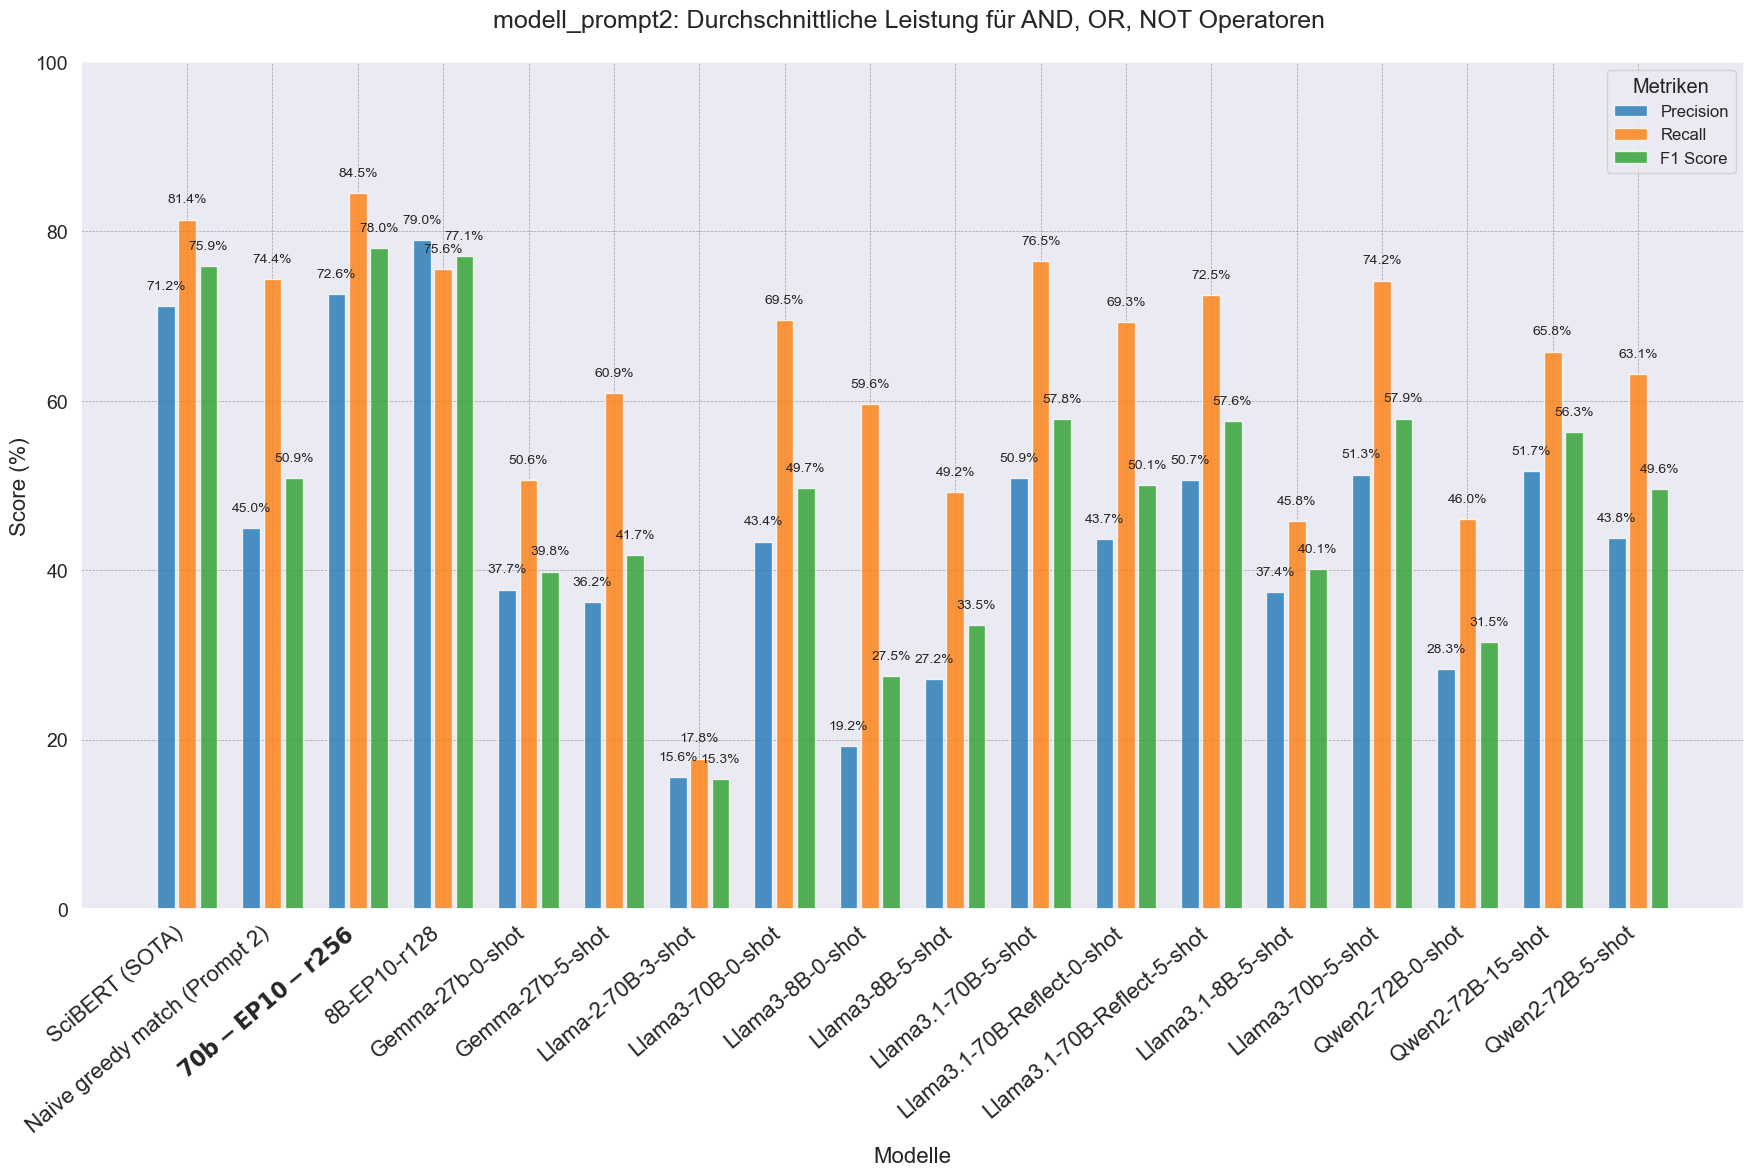

In [8]:
plot_avg_metrics(all_metrics, versuch_name)

In [9]:
#5_shot_max_temp
def plot_f1_scores_temperatur(all_metrics):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    temperatures = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    f1_scores_70b = []
    f1_scores_llama3_5shot = []
    f1_scores_llama3_0shot = []

    for temp in temperatures:
        f1_scores_70b.append(all_metrics[f'70b_EP10_r256_temp{temp:.1f}']['average']['f1'])
        f1_scores_llama3_5shot.append(all_metrics[f'Llama-3-70B_5_shot_max_{temp:.1f}']['average']['f1'])
        f1_scores_llama3_0shot.append(all_metrics[f'Llama-3-70B-Instruct_0_shot_{temp:.1f}']['average']['f1'])

    x = np.arange(len(temperatures))
    bar_width = 0.25

    plt.figure(figsize=(16, 8)) 
    sns.set_style("whitegrid")

    # Balken
    plt.bar(x - bar_width, f1_scores_70b, bar_width, alpha=0.8, color='#A9D0F5', label='Fine-Tuned')
    plt.bar(x, f1_scores_llama3_5shot, bar_width, alpha=0.8, color='#FFA07A', label='5-Shot')
    plt.bar(x + bar_width, f1_scores_llama3_0shot, bar_width, alpha=0.8, color='#90EE90', label='0-Shot')

    # Linien
    plt.plot(x - bar_width, f1_scores_70b, color='blue', linestyle='-', linewidth=2)
    plt.plot(x, f1_scores_llama3_5shot, color='red', linestyle='-', linewidth=2)
    plt.plot(x + bar_width, f1_scores_llama3_0shot, color='green', linestyle='-', linewidth=2)

    # Punkte mittig auf den Balken
    plt.scatter(x - bar_width, f1_scores_70b, color='blue', s=50, zorder=3)
    plt.scatter(x, f1_scores_llama3_5shot, color='red', s=50, zorder=3)
    plt.scatter(x + bar_width, f1_scores_llama3_0shot, color='green', s=50, zorder=3)

    plt.xlabel('Temperatur', fontsize=14, fontweight='bold', labelpad=15)
    plt.ylabel('F1-Score', fontsize=14, fontweight='bold', labelpad=15)
    plt.title('Llama3 70B Temperatur Evaluation', fontsize=16, fontweight='bold', pad=20)

    plt.xticks(x, temperatures, fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0, 100)

    plt.legend(fontsize=12, loc='upper right')

    # Werte auf den Balken mit Prozentzeichen
    for i, v in enumerate(f1_scores_70b):
        plt.text(i - bar_width, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    for i, v in enumerate(f1_scores_llama3_5shot):
        plt.text(i, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    for i, v in enumerate(f1_scores_llama3_0shot):
        plt.text(i + bar_width, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'data/pics/Temperatur.png')
    plt.show()

plot_f1_scores_temperatur(all_metrics)

KeyError: '70b_EP10_r256_temp0.1'

In [ ]:
import pandas as pd

def create_latex_table(all_metrics):
    temperatures = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    data = {
        'Temperatur': temperatures,
        'Fine-Tuned': [],
        '5-Shot': [],
        '0-Shot': []
    }

    for temp in temperatures:
        data['Fine-Tuned'].append(all_metrics[f'70b_EP10_r256_temp{temp:.1f}']['average']['f1'])
        data['5-Shot'].append(all_metrics[f'Llama-3-70B_5_shot_max_{temp:.1f}']['average']['f1'])
        data['0-Shot'].append(all_metrics[f'Llama-3-70B-Instruct_0_shot_{temp:.1f}']['average']['f1'])

    df = pd.DataFrame(data)

    # Runde alle Werte auf eine Dezimalstelle
    df = df.round(1)

    latex_table = df.to_latex(index=False, column_format='c|ccc', escape=False)

    # Füge LaTeX-Formatierung hinzu
    latex_table = f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{F1-Scores für verschiedene Temperaturen und Modellkonfigurationen}}
\\label{{tab:temperature-f1-scores}}
{latex_table}
\\end{{table}}
"""

    # Speichere die LaTeX-Tabelle in einer Datei
    with open('data/latex/temperature_f1_scores_table.tex', 'w') as f:
        f.write(latex_table)

    print(latex_table)

# Verwendung der Funktion
create_latex_table(all_metrics)

In [10]:
def avg_operators_latex(all_metrics, versuch_name):
    metrics_to_plot = ['precision', 'recall', 'f1']

    # SOTA metrics
    sota_metrics = {
        'SciBERT (SOTA)': {
            'average': {'precision': 71.16, 'recall': 81.39, 'f1': 75.89}
        },
        'R-BERT + SciBERT': {
            'average': {'precision': 72.23, 'recall': 78.23, 'f1': 75.0}
        }
    }

    max_values = {metric: float('-inf') for metric in metrics_to_plot}
    for model_metrics in [*sota_metrics.values(), *all_metrics.values()]:
        for metric in metrics_to_plot:
            value = model_metrics['average'][metric]
            if value > max_values[metric]:
                max_values[metric] = value

    latex_table = "\\begin{table}[ht]\n"
    latex_table += "\\centering\n"
    latex_table += "\\begin{tabular}{lcccc}\n"
    latex_table += "\\toprule\n"
    latex_table += "Model & Precision & Recall & F1 & Halluzination (%) \\\\\n"
    latex_table += "\\midrule\n"

    # Add rows for SOTA models
    for name, values in sota_metrics.items():
        row = name.replace("_", "-")
        for metric in metrics_to_plot:
            value = values['average'][metric]
            formatted_value = "{:.1f}".format(value)
            if value == max_values[metric]:
                formatted_value = f"\\textbf{{{formatted_value}}}"
            row += f" & {formatted_value}"
        row += " & - \\\\\n"  # No zuviel percentage for SOTA models
        latex_table += row

    # Add rows for other models
    for model, model_metrics in all_metrics.items():
        row = model.replace("_", "-")
        for metric in metrics_to_plot:
            value = model_metrics['average'][metric]
            formatted_value = "{:.1f}".format(value)
            if value == max_values[metric]:
                formatted_value = f"\\textbf{{{formatted_value}}}"
            row += f" & {formatted_value}"
        # Add average zuviel percentage value
        zuvielpct_value = model_metrics['average_zuviel_percentage']
        formatted_zuvielpct_value = "{:.1f}".format(zuvielpct_value)
        row += f" & {formatted_zuvielpct_value} \\\\\n"
        latex_table += row

    latex_table += "\\bottomrule\n"
    latex_table += "\\end{tabular}\n"
    latex_table += f"\\caption{{Average Model Performance Metrics and Zuviel Percentage for {versuch_name}}}\n"
    latex_table += "\\label{tab:avg_model_metrics}\n"
    latex_table += "\\end{table}\n"

    os.makedirs("latex", exist_ok=True)
    with open(f"data/latex/{versuch_name}.tex", "w") as file:
        file.write(latex_table)
    return latex_table


  ### Durchschnittliche Performance über alle Operatoren [AND, OR, NOT] to LATEX

In [11]:
avg_operators_latex(all_metrics, versuch_name)

'\\begin{table}[ht]\n\\centering\n\\begin{tabular}{lcccc}\n\\toprule\nModel & Precision & Recall & F1 & Halluzination (%) \\\\\n\\midrule\nSciBERT (SOTA) & 71.2 & 81.4 & 75.9 & - \\\\\nR-BERT + SciBERT & 72.2 & 78.2 & 75.0 & - \\\\\n Naive greedy match (Prompt 2) & 45.0 & 74.4 & 50.9 & 1.3 \\\\\n70b-EP10-r256 & 72.6 & \\textbf{84.5} & \\textbf{78.0} & 0.5 \\\\\n8B-EP10-r128 & \\textbf{79.0} & 75.6 & 77.1 & 0.4 \\\\\nGemma-27b-0-shot & 37.7 & 50.6 & 39.8 & 2.8 \\\\\nGemma-27b-5-shot & 36.2 & 60.9 & 41.7 & 4.7 \\\\\nLlama-2-70B-3-shot & 15.6 & 17.8 & 15.3 & 50.8 \\\\\nLlama-3-70B-0-shot & 43.4 & 69.5 & 49.7 & 3.9 \\\\\nLlama-3-8B-0-shot & 19.2 & 59.6 & 27.5 & 40.4 \\\\\nLlama-3-8B-Instruct-5-shot & 27.2 & 49.2 & 33.5 & 19.1 \\\\\nLlama-3.1-70B-5-shot & 50.9 & 76.5 & 57.8 & 1.6 \\\\\nLlama-3.1-70B-Reflect-0-shot & 43.7 & 69.3 & 50.1 & 3.4 \\\\\nLlama-3.1-70B-Reflect-5-shot & 50.7 & 72.5 & 57.6 & 1.4 \\\\\nLlama-3.1-8B-Instruct-5-shot & 37.4 & 45.8 & 40.1 & 8.4 \\\\\nLlama3-70b-5-shot & 51

### Perfomance der einzelnen Operatoren

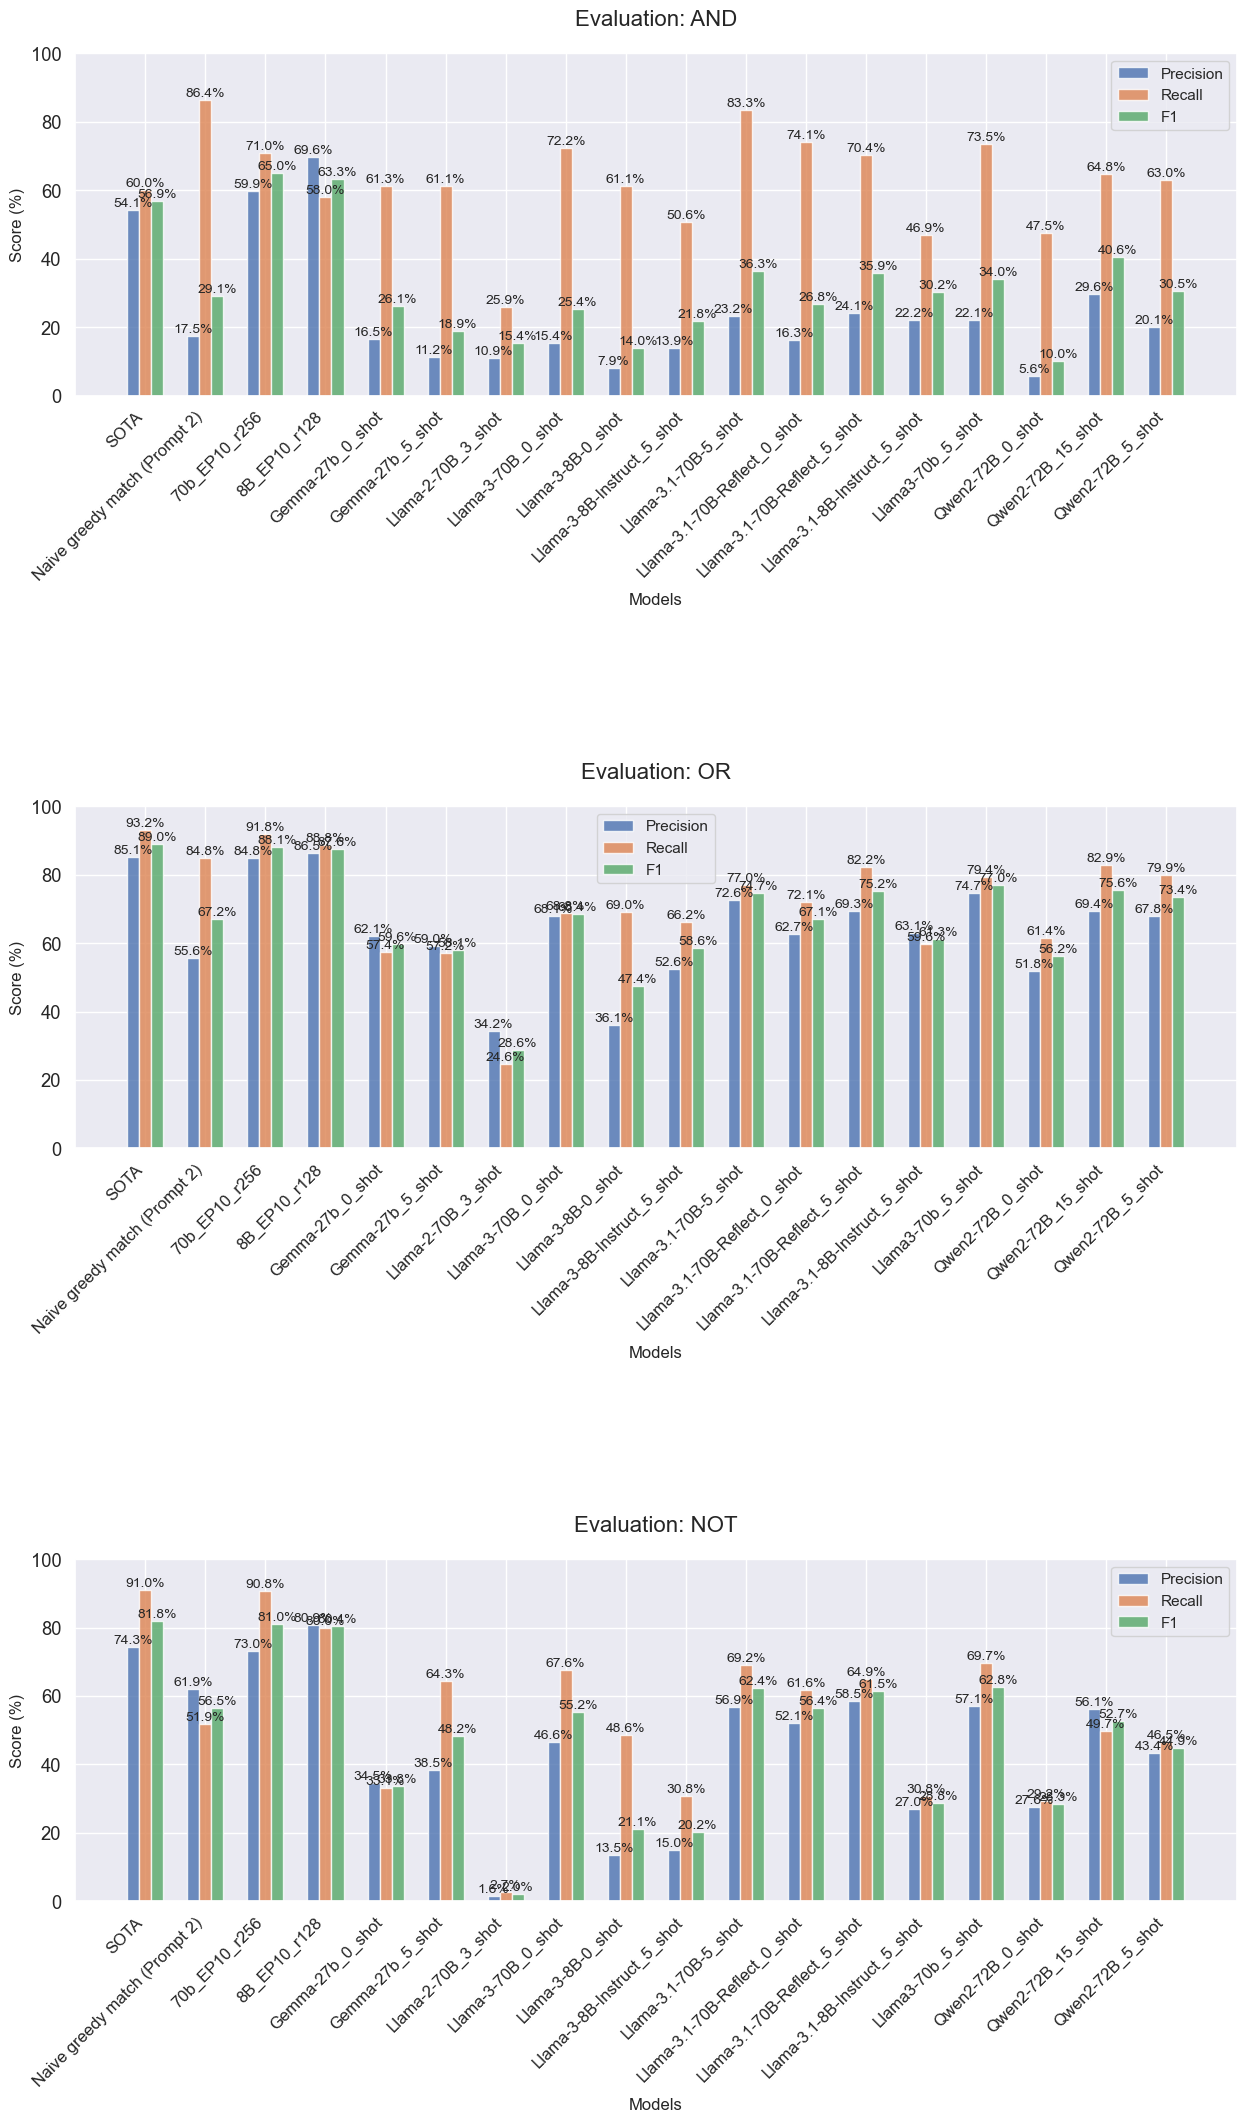

In [12]:
plot_metrics(all_metrics)

### Plot Anzahl Operators

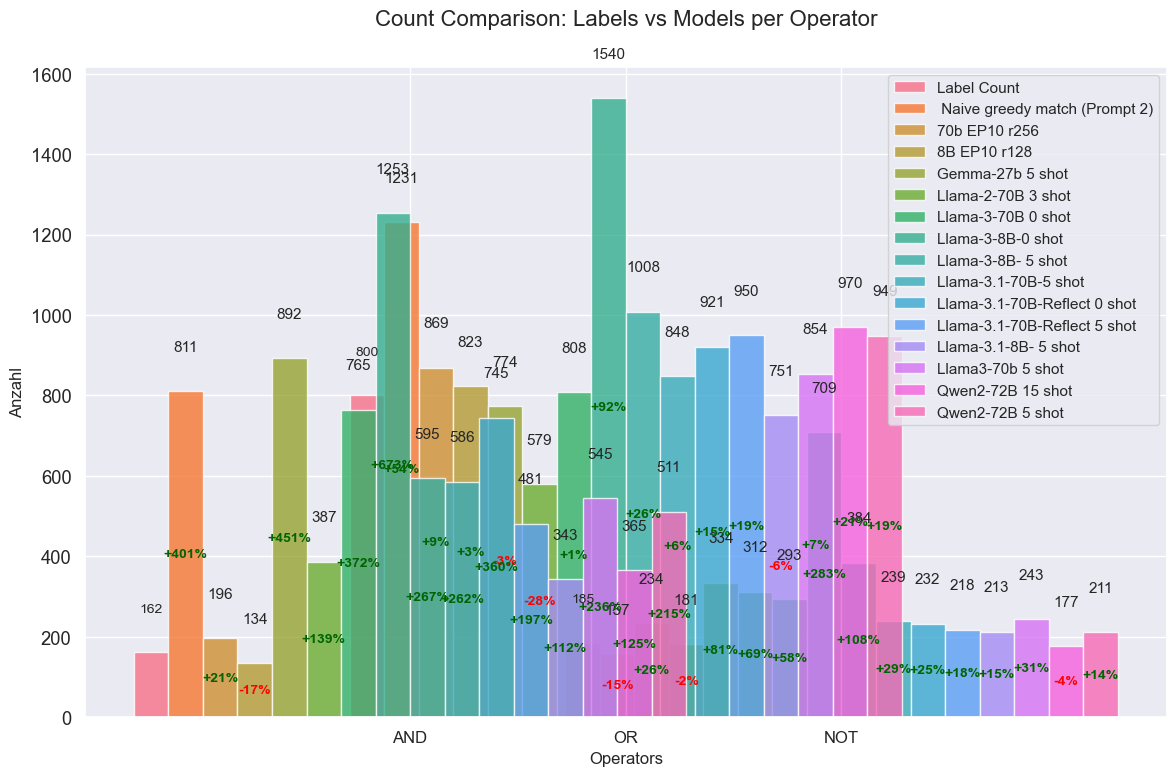

In [12]:
plot_count_comparison(all_metrics)

### Evaluiere n-shot Modelle

## Model vs SOTA


In [13]:
print(models)

model_to_plot = models[len(models)-2] # len(models)-1
model_name = model_to_plot
model_to_plot

[' Naive greedy match (Prompt 2)', '70b_EP10_r256', '8B_EP10_r128', 'Gemma-27b_5_shot', 'Llama-2-70B_3_shot', 'Llama-3-70B_0_shot', 'Llama-3-8B-0_shot', 'Llama-3-8B-Instruct_5_shot', 'Llama-3.1-70B-5_shot', 'Llama-3.1-70B-Reflect_0_shot', 'Llama-3.1-70B-Reflect_5_shot', 'Llama-3.1-8B-Instruct_5_shot', 'Llama3-70b_5_shot', 'Qwen2-72B_15_shot', 'Qwen2-72B_5_shot']


'Qwen2-72B_15_shot'

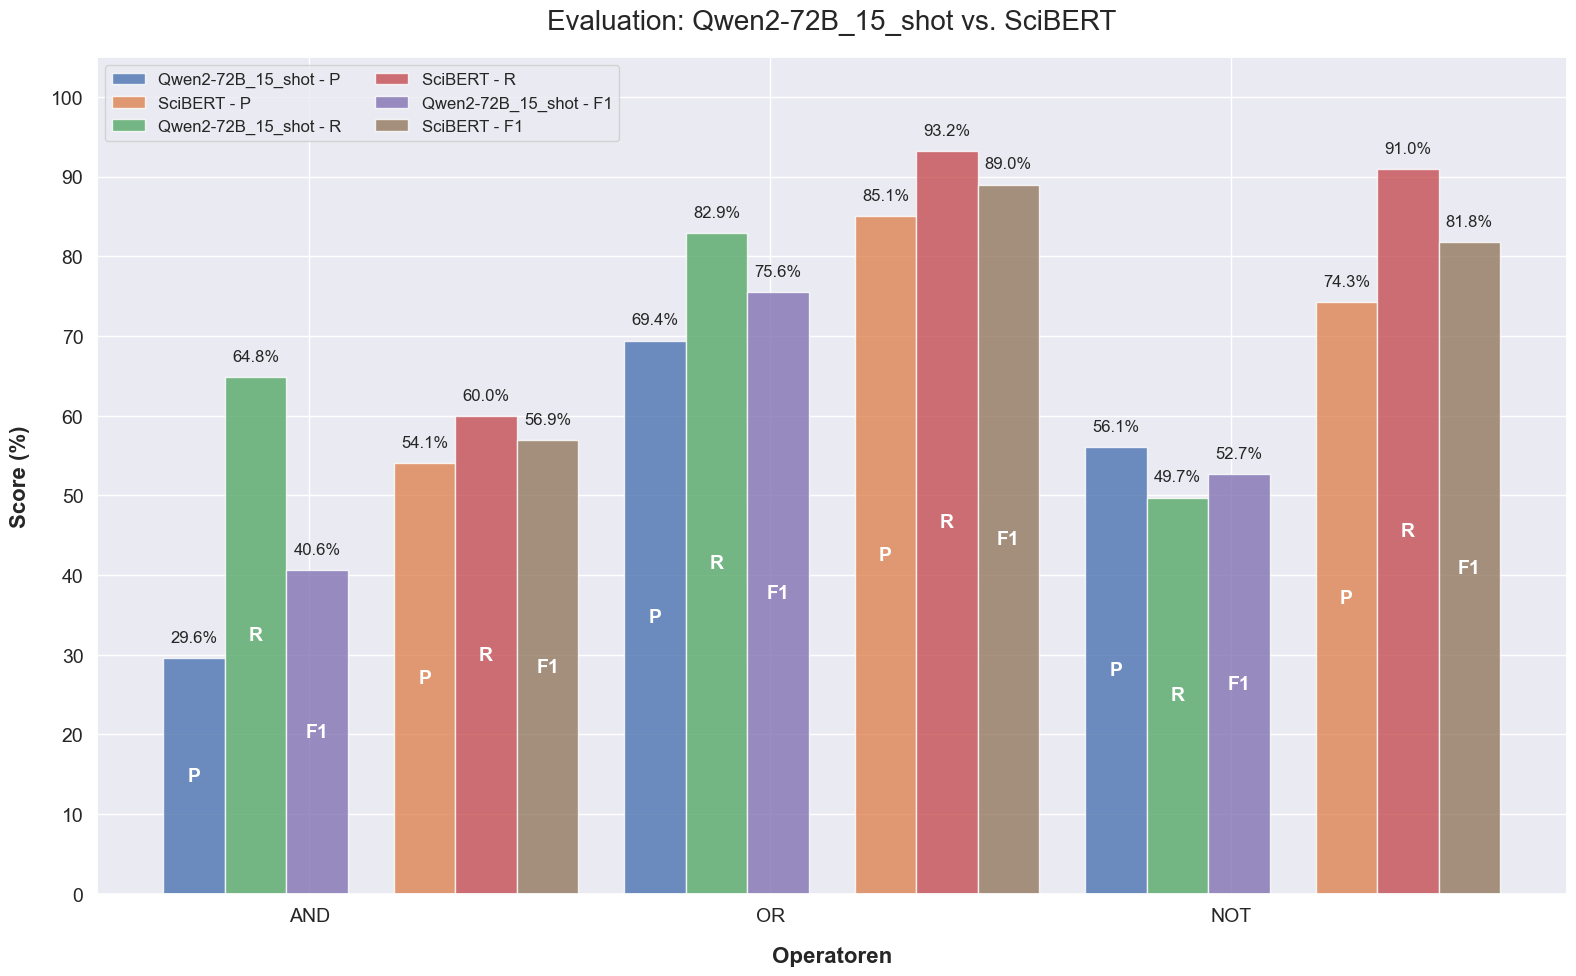

In [14]:
model_metrics = all_metrics[model_to_plot]


sota_metrics = {
    'SciBERT': {
        'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
        'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
        'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0},
        'average': {'precision': 71.16, 'recall': 81.39, 'f1': 75.89}
    },
    'R-BERT + SciBERT': {
        'AND': {'precision': 53.8, 'recall': 53.8, 'f1': 53.8},
        'NOT': {'precision': 74.5, 'recall': 88.7, 'f1': 81.0},
        'OR': {'precision': 88.4, 'recall': 92.2, 'f1': 90.2},
        'average': {'precision': 72.23, 'recall': 78.23, 'f1': 75.0}
    }
}

operators = ['AND', 'OR', 'NOT']
metrics_to_plot = ['precision', 'recall', 'f1']
metric_labels = {'precision': 'P', 'recall': 'R', 'f1': 'F1'}

fig, ax = plt.subplots(figsize=(16, 10))

x = np.arange(len(operators))
bar_width = 0.4
opacity = 0.8
gap = 0.1

for i, metric in enumerate(metrics_to_plot):
    model_values = [model_metrics[op][metric] for op in operators]
    sota_values = [sota_metrics['SciBERT'][op][metric] for op in operators]

    ax.bar(x - bar_width/2 - gap/2 + i*bar_width/3, model_values, bar_width/3, alpha=opacity, label=f'{model_name.split("-Instruct")[0]} - {metric_labels[metric]}')
    ax.bar(x + bar_width/2 + gap/2 + i*bar_width/3, sota_values, bar_width/3, alpha=opacity, label=f'SciBERT - {metric_labels[metric]}')

    for j, (model_value, sota_value) in enumerate(zip(model_values, sota_values)):
        ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
        ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

        ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value + 2, f'{model_value:.1f}%', ha='center', fontsize=12)
        ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value + 2, f'{sota_value:.1f}%', ha='center', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(operators, fontsize=14)
ax.set_xlabel('Operatoren', fontsize=16, fontweight='bold', labelpad=15)
ax.set_ylabel('Score (%)', fontsize=16, fontweight='bold', labelpad=15)
ax.set_ylim(0, 105)
ax.set_yticks(np.arange(0, 101, 10))
ax.tick_params(axis='y', labelsize=14, width=2)
ax.yaxis.set_tick_params(labelsize=14)
ax.set_title(f'Evaluation: {model_name} vs. SciBERT', fontsize=20, pad=20)
ax.legend(fontsize=12, ncol=2, loc='upper left')
ax.grid(True)

plt.tight_layout()
#plt.savefig(f"pics/{model_to_plot}_vs_sota__{versuch_name}.png")
plt.show()

#### AND OR NOT Einzeln EVALUATION LATEX

In [15]:
and_or_not_to_latex(all_metrics, versuch_name)

'\\begin{table}[ht]\n\\centering\n\\begin{tabular}{lccccccccc}\n\\toprule\nModel & \\multicolumn{3}{c}{AND} & \\multicolumn{3}{c}{OR} & \\multicolumn{3}{c}{NOT} \\\\\n\\cmidrule(lr){2-4} \\cmidrule(lr){5-7} \\cmidrule(lr){8-10} \n & P & R & F & P & R & F & P & R & F \\\\\n\\midrule\nSciBERT (SOTA) & 54.1 & 60.0 & 56.9 & 85.1 & \\textbf{93.2} & 89.0 & 74.3 & \\textbf{91.0} & \\textbf{81.8} \\\\\nR-BERT + SciBERT & 53.8 & 53.8 & 53.8 & \\textbf{88.4} & 92.2 & \\textbf{90.2} & 74.5 & 88.7 & 81.0 \\\\\n Naive greedy match (Prompt 2) & 17.5 & \\textbf{86.4} & 29.1 & 55.6 & 84.8 & 67.2 & 61.9 & 51.9 & 56.5 \\\\\n70b-EP10-r256 & 59.9 & 71.0 & \\textbf{65.0} & 84.8 & 91.8 & 88.1 & 73.0 & 90.8 & 81.0 \\\\\n8B-EP10-r128 & \\textbf{69.6} & 58.0 & 63.3 & 86.5 & 88.8 & 87.6 & \\textbf{80.9} & 80.0 & 80.4 \\\\\nGemma-27b-5-shot & 11.2 & 61.1 & 18.9 & 59.0 & 57.2 & 58.1 & 38.5 & 64.3 & 48.2 \\\\\nLlama-2-70B-3-shot & 10.9 & 25.9 & 15.4 & 34.2 & 24.6 & 28.6 & 1.6 & 2.7 & 2.0 \\\\\nLlama-3-70B-0-shot &